In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data= pd.read_excel('/content/drive/MyDrive/analitica neg/2. Travel_Plan_Data.xlsx', sheet_name=0)
score=pd.read_excel('/content/drive/MyDrive/analitica neg/2. Travel_Plan_Data.xlsx', sheet_name=1)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     200 non-null    int64  
 1   CreditCard  200 non-null    int64  
 2   FoodSpend   200 non-null    float64
 3   Income      200 non-null    int64  
 4   TravelPlan  200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [ ]:
score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     2 non-null      int64  
 1   CreditCard  2 non-null      int64  
 2   FoodSpend   2 non-null      float64
 3   Income      2 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 196.0 bytes


In [ ]:
data[['College','CreditCard']]= data[['College','CreditCard']].astype(str).replace({'Yes':1,'No':0})
score[['College']]= score[['College']].astype(str).replace({'Yes':1,'No':0})

In [ ]:
data

,College,CreditCard,FoodSpend,Income,TravelPlan
0,0,0,2905.97,65982,1
1,1,0,4677.03,57274,1
2,0,0,5068.53,58520,1
3,0,1,4252.09,47330,0
4,0,0,6438.27,54422,1
...,...,...,...,...,...
195,0,1,3405.75,46050,0
196,0,0,2892.90,65982,1
197,0,0,9129.66,59676,1
198,1,1,5550.56,47806,0


In [ ]:
score

,College,CreditCard,FoodSpend,Income
0,0,1,2892.90,65982
1,1,0,6017.66,53986


In [ ]:
XD = data[['College','CreditCard','FoodSpend', 'Income',]]##variables dependientes
YD= data[['TravelPlan']] ##variable dependiente (la que vamos a predecir)

###Descripción de las variables


College: Muestra si la persona fue a la universidad o no. Puede ayudar a ver si la educación influye en cómo y cuánto viajan.

CreditCard: Indica si alguien tiene tarjeta de crédito. Útil para entender cómo pueden pagar sus viajes y qué tan accesibles son ciertos destinos o gastos para ellos.

FoodSpend: Es lo que gastan en comida. Ayuda a ver qué tan importante es la comida en su presupuesto de viaje.

Income: Cuánto gana la persona. Esto da una idea de cuánto pueden gastar en viajes y qué tipo de planes pueden permitirse.

TravelPlan: Muestra si tienen un viaje planeado o no. Sirve para ver qué factores influyen en la decisión de viajar, como sus ingresos o hábitos de gasto.

In [ ]:
## importo las librerias necesarias
import pandas as pd, numpy as np, matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix


In [ ]:
DTModel= DecisionTreeClassifier(criterion='gini', max_depth=4)

In [ ]:
DTModel.fit(XD,YD)

DecisionTreeClassifier(max_depth=4)

In [ ]:
ydPred=DTModel.predict(XD)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(YD, ydPred)
cm

array([[105,  16],
       [ 31,  48]])

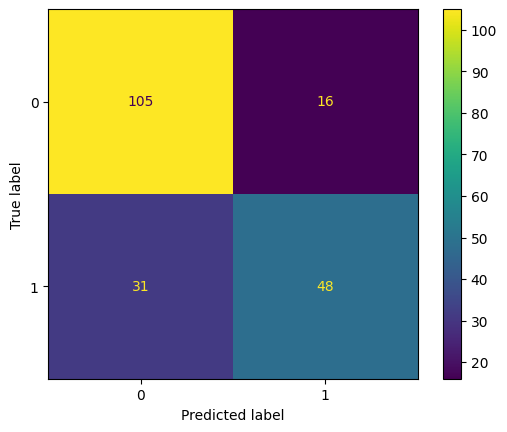

In [ ]:
import matplotlib.pyplot as plt
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DTModel.classes_)
disp.plot()
plt.show()

In [ ]:
# Metricas de evaluacion
# Extraigo los valores de la matriz de confusion
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]
#metricas
#exactitud (Accuracy)
exactitud = (VN+VP)/cm.sum()
print(f'la exactitud (accurazy) del modelo es: {exactitud:.2%}')

#Tasa de error
error= 1-exactitud
print(f'la tasa de error del modelo es: {error:.2%}')

#precision
precision = VP/(VP+FP)
print(f'la precision del modelo es: {precision:.2%}')

#sensibilidad
sensibilidad = VP/(VP+FN)
print(f'la sensibilidad del modelo es: {sensibilidad:.2%}')

#Especificidad
especificidad = VN/(VN+FP)
print(f'la especificidad del modelo es: {especificidad:.2%}')

la exactitud (accurazy) del modelo es: 76.50%
la tasa de error del modelo es: 23.50%
la precision del modelo es: 75.00%
la sensibilidad del modelo es: 60.76%
la especificidad del modelo es: 86.78%


In [ ]:

## Generalizo el modelo con los datos de score (son datos no conocidos previamente por el modelo)
ydGener = DTModel.predict(score)

In [ ]:
ydGener

array([0, 0])

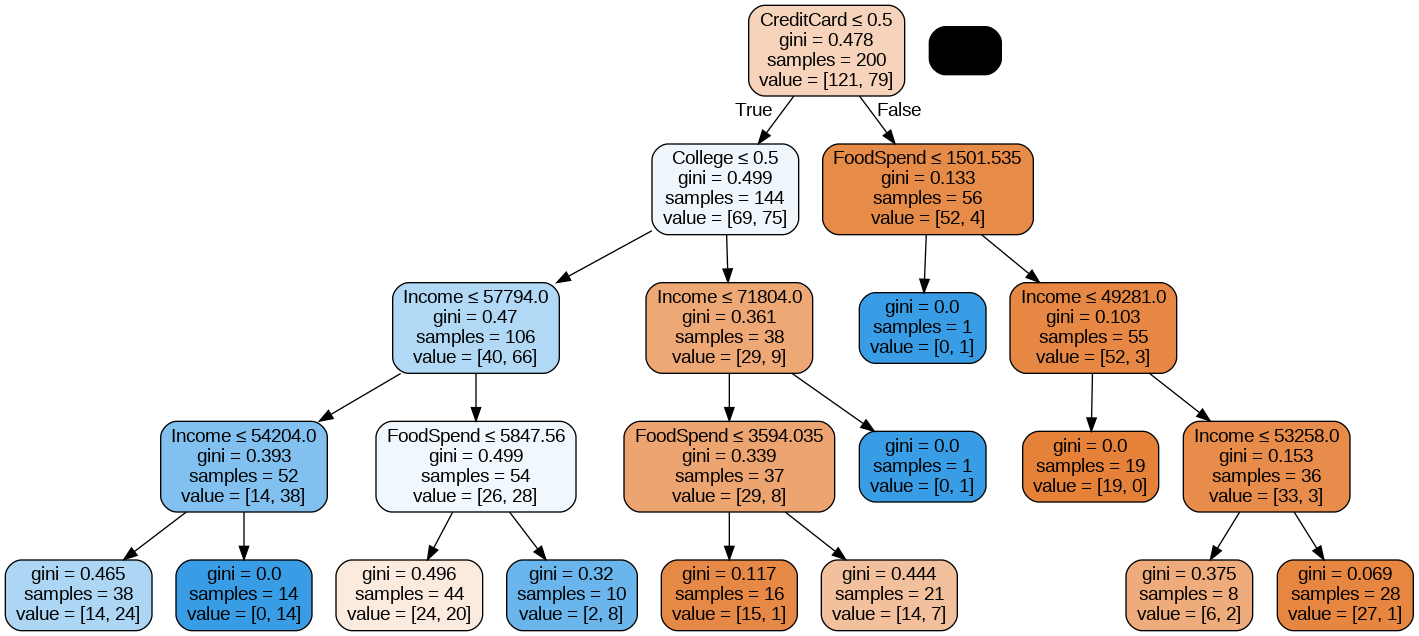

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

vars= ['College','CreditCard','FoodSpend', 'Income',]
dot_data = StringIO()
export_graphviz(DTModel, out_file=dot_data, feature_names=vars, filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

#Pronostico primer cliente vaya a viajar el proximo año

IF CREDITCARD > 0.5 AND FOODSPEND > 1501 > AND INCOME > 53258

27/28 =0,964 la probabilidad de que el primer individuo vaya a viajar el proximo año es de 96%

#Pronostico SEGUNDO cliente vaya a viajar el proximo año

IF CREDITCARD <= O.5 AND COLLEGE <= 0.5 AND INCOME <= 71804 AND food spend > 3594

14/21 = 0, 66

La probabilidad de que el segundo individuo vaya a viajar el proximo año es de 66% aproximadamente


#NODOS PUROS

1.IF creditcard > 0.5 and foodspend > 1501.535 and income <= 49281


2.if creditcard > 0.5 and foodspend <= 1501



3.if creditcard < 0.5 and college <= 0.5 and income >= 71804



4.if credit card < 0.5 and college <= 0.5 and income <= 57794 and income >54204


